In [1]:
import os

from io import StringIO
from google.cloud import storage
from dotenv import load_dotenv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from transformers import AutoModelForCausalLM
from transformers import AutoTokenizer, EsmForMaskedLM
from tokenizers import Tokenizer
from peft import get_peft_model, LoraConfig, TaskType


/opt/anaconda3/envs/MachLearn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from plm_compare_progen2 import *
from plm_compare_esm import *
from protein_data import *

In [3]:
with open('/Users/johnhutchens/Desktop/Practicum/Data/Wild_Dictionaries/pg2_ProGym_matrices.pickle',
           'rb') as f:
    pg_dict = pickle.load(f)

In [4]:
# inserts mutation amino acid in corresponding position in protein sequence
def insert_wt(seq, pos, wt_aa):
    seq_list = list(seq)
    pos = int(pos)
    if pos < len(seq_list):
        seq_list[pos] = wt_aa
    return ''.join(seq_list)

# computes the ranking loss between two iterables
def listwise_ranking_loss(preds, targets):
    indices = targets.sort(descending=True).indices
    preds = torch.gather(preds, dim=-1, index=indices)
    cumsums = preds.exp().flip(dims=[-1]).cumsum(dim=-1).flip(dims=[-1])
    loss = torch.log(cumsums + 1e-10) - preds
    return loss.mean()

def FineTune_ProGen2_LORA(device, base_model, tokenizer, lora_config, 
                          protein_seq, target_tensor, loss_fn, 
                          lrate=-1e-5, num_epochs=5, k=0.5, 
                          num_samples=20, print_info=True):
    '''
    device is GPU or CPU
    base_model is ProGen2 model
    tokenizer is ProGen2 tokenizer
    lora_config is data for peft lora fine tuning 
    lr is learning rate for gradien descent on new layer
    protein sequence is the sequence lora layer is being trained on
    target_tensor is what loss is measured against initially this is the actual protein sequence
    loss_fn is loss function used in training and validation
    num_epochs is the number of training steps
    k is the proportion of sequence used in training. validation and test indices are created as half the remaining indices each
    num_samples is the number of sample drawn for each epoch used for training and validation
    '''
    amino_acids = 'ACDEFGHIKLMNPQRSTVWY'
    aa_token_ids = [tokenizer.convert_tokens_to_ids(aa) for aa in amino_acids]

    model = get_peft_model(base_model, lora_config)

    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lrate)

    exp_tensor = target_tensor
    seq_len = exp_tensor.shape[0]

    all_indices = torch.randperm(seq_len)

    num_train = int(seq_len * k)
    num_val   = int(seq_len * k/2)
    num_test  = seq_len - num_train - num_val

    train_indices = all_indices[:num_train] # len 900
    val_indices   = all_indices[num_train:num_train + num_val]
    test_indices  = all_indices[num_train + num_val:]

    train_losses = []
    val_losses = []
    early_stop_count = 0


    vocab_dict = tokenizer.get_vocab()
    seq_list = list(protein_seq)
    inputs = tokenizer(protein_seq, return_tensors="pt").to(device)

    for epoch in range(num_epochs):

        model.train()
        outputs = model(**inputs)
        logits = outputs.logits.squeeze(0)  # (seq_len, vocab_size)
        wt_logits = torch.log_softmax(logits, dim=-1)
        residue_indices = torch.arange(len(protein_seq))

        # ignoring BOS token
        seq_indices = [vocab_dict[aa] for aa in seq_list]
        wt_norm_tensor = wt_logits[residue_indices, seq_indices].unsqueeze(-1)
        LLR_tensor = wt_logits - wt_norm_tensor
        LLR_tensor_aa_only = LLR_tensor[:, aa_token_ids]

        # flatten the LLR_tensor
        flattened_LLR_tensor = LLR_tensor_aa_only.flatten()
        flattened_exp_tensor = exp_tensor.to(device)
        flattened_LLR_tensor = flattened_LLR_tensor.to(device)

        #to stack
        combined = torch.stack([flattened_LLR_tensor, flattened_exp_tensor], dim=0)
        ft_tensor = torch.transpose(combined, 0, 1)

        # predicted_scores = []
        # experimental_values = []

        train_tensor = ft_tensor[train_indices]

        #drop nan
        train_tensor = train_tensor[~torch.any(train_tensor.isnan(), dim=1)]

        # num_samples = num_samples
        positions = train_tensor[torch.randperm(len(train_tensor))[:num_samples]]

        predicts = positions[:, 0] #LLR
        targets = positions[:, 1] #exp

        # Compute loss with predicts and targets
        loss = loss_fn(predicts, targets)
        # log_probs = torch.log_softmax(logits, dim=-1)
        # loss = -log_probs[torch.arange(len(seq_indices)), seq_indices].mean() # needs to be difference of predict/target
        loss.backward()
        # for name, param in model.named_parameters():
        #     if param.requires_grad:
        #         print(name, param.grad.abs().mean())
        optimizer.step()
        optimizer.zero_grad()

        train_losses.append(loss.item())

        # ----------- VALIDATION (no backprop) -----------
        model.eval()
        with torch.no_grad():
            val_tensor = ft_tensor[val_indices]
            val_tensor = val_tensor [~torch.any(val_tensor.isnan(), dim=1)]

            # num_samples = 45
            positions = val_tensor[torch.randperm(len(val_tensor))[:num_samples]]

            predicts = positions[:, 0] #LLR
            targets = positions[:, 1] #exp

            val_loss = loss_fn(predicts, targets)
            # val_loss = listwise_ranking_loss(predicts, targets)
            #   val_log_probs = torch.log_softmax(logits, dim=-1)
            #   val_loss = -log_probs[torch.arange(len(seq_indices)), seq_indices].mean()
            val_losses.append(val_loss.item())

        if print_info==True:
            print(f"Epoch {epoch+1} - Training Loss: {loss.item():.4f} | Validation Loss: {val_loss.item():.4f}")

            if val_loss.item() > loss.item():
                early_stop_count += 1
            else:
                early_stop_count = 0
                
            print(f"Validation loss has exceeded training loss {early_stop_count} time(s) in a row")
            # if early_stop_count > 2:
            #     print("Validation loss exceeded training loss 3 times — early stopping.")
            #     break

    return model, val_loss
# , ft_tensor, test_indices

In [5]:
device = 'cpu'
print(f"Using {device} device")
model_name = "hugohrban/progen2-medium"
base_model, tokenizer = initialize_progen2_noeval(model_name)

Using cpu device


In [6]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    # target_modules=["query", "key", "value", "output.dense"],
    target_modules=["qkv_proj", "out_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.FEATURE_EXTRACTION
    # task_type=TaskType.CAUSAL_LM
)

protein_seq = 'EDGINLEEIREFAKNFKIRRLSLGLTQTQVGQALTATEGPAYSQSAICRFEKLDITPKSAQKLKPVLEKWLNEAELRNQEGQQNLMEFVG'

df_mutation = pd.read_csv('mutation.csv') # automate df_mutation
fitness_data = df_mutation
fitness_data.reset_index(drop=True, inplace=True)
positions = np.arange(len(protein_seq))

amino_acids = 'ACDEFGHIKLMNPQRSTVWY'
aa_token_ids = [tokenizer.convert_tokens_to_ids(aa) for aa in amino_acids]
positions_col = np.repeat(positions, len(amino_acids))
amino_acids_col = np.tile(list(amino_acids), len(positions))
df2 = pd.DataFrame({'real_position': positions_col, 'mut_aa': amino_acids_col})
df_merged = df2.merge(
    fitness_data,
    on=['real_position', 'mut_aa'],
    how='left')
fitness_list = df_merged['normalized_fitness'].tolist()
fitness_tensor = torch.tensor(fitness_list)
exp_tensor = fitness_tensor
seq_len = exp_tensor.shape[0]

loss = listwise_ranking_loss



In [13]:
model, val_loss = FineTune_ProGen2_LORA(device, base_model, tokenizer, lora_config, protein_seq, exp_tensor, loss, lr=-1e-5, num_epochs=5, k=0.5, num_samples=20)

Epoch 1 - Training Loss: 2.9886 | Validation Loss: 4.0237
Validation loss has exceeded training loss 1 time(s) in a row
Epoch 2 - Training Loss: 7.7011 | Validation Loss: 3.4949
Validation loss has exceeded training loss 0 time(s) in a row
Epoch 3 - Training Loss: 3.4297 | Validation Loss: 3.2316
Validation loss has exceeded training loss 0 time(s) in a row
Epoch 4 - Training Loss: 6.4405 | Validation Loss: 7.7669
Validation loss has exceeded training loss 1 time(s) in a row
Epoch 5 - Training Loss: 4.1019 | Validation Loss: 3.7896
Validation loss has exceeded training loss 0 time(s) in a row


In [7]:
num_epochs = [1, 10, 100, 1000]
l_rates = [1e-1, 1e-2, 1e-3, 1e-4]
len_ep = len(num_epochs)
len_lr = len(l_rates)

results = {}


for i in range(len_ep):
    eps = num_epochs[i]
    results[eps] = []
    # print(f"Number of epochs: {eps}")
    for j in range(len_lr):
        lr = l_rates[j]
        # print(f"Learning rate: {lr}")
        
        model, val_loss = FineTune_ProGen2_LORA(device, base_model, tokenizer, 
                                                lora_config, protein_seq, exp_tensor, 
                                                loss, lrate=lr, num_epochs=eps, k=0.5, 
                                                num_samples=20, print_info=False)
        
        # print(f"Validation loss = {val_loss}")
        results[eps].append(val_loss)

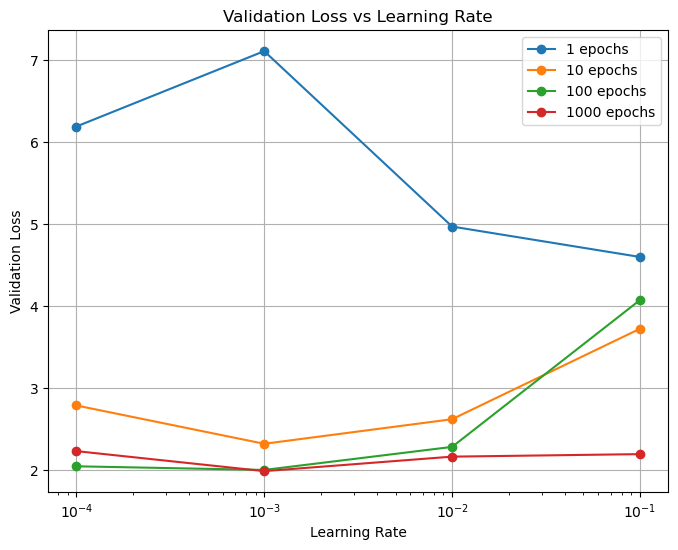

In [8]:
plt.figure(figsize=(8,6))

for eps, losses in results.items():
    plt.plot(l_rates, losses, marker='o', label=f'{eps} epochs')

plt.xscale('log')   # learning rates should be log-scaled
plt.xlabel('Learning Rate')
plt.ylabel('Validation Loss')
plt.title('Validation Loss vs Learning Rate')
plt.legend()
plt.grid(True)

plt.show()

In [48]:
load_dotenv()
cred_path = os.getenv('GOOGLE_APPLICATION_CREDENTIALS')

os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = cred_path

client = storage.Client()
bucket = client.bucket('domainome-data')
blob = bucket.blob('SupplementaryTable2.txt')

df = pd.read_csv(StringIO(blob.download_as_text()), sep='\t')

In [49]:
df.head()

,domain_ID,uniprot_ID,aa_seq,wt_aa,position,mut_aa,STOP,input_count_rep1,input_count_rep2,input_count_rep3,output_count_rep1,output_count_rep2,output_count_rep3,mean_input_count,fitness,fitness_sigma,normalized_fitness,normalized_fitness_sigma,quality_rank
0,A0A2R8Y422_PF00240_2,A0A2R8Y422,*IFVKTLMGKTITLEVELSDTIDNVKAKIQDKEGIPPDQQRLIFAG...,Q,2.0,*,True,118.0,113.0,62.0,10.0,29.0,2.0,97.66667,0.030945,0.014885,-0.819050,0.208478,339
1,A0A2R8Y422_PF00240_2,A0A2R8Y422,AIFVKTLMGKTITLEVELSDTIDNVKAKIQDKEGIPPDQQRLIFAG...,Q,2.0,A,False,219.0,277.0,217.0,86.0,225.0,137.0,237.66670,0.069376,0.006673,-0.280790,0.093461,339
2,A0A2R8Y422_PF00240_2,A0A2R8Y422,CIFVKTLMGKTITLEVELSDTIDNVKAKIQDKEGIPPDQQRLIFAG...,Q,2.0,C,False,706.0,726.0,459.0,768.0,507.0,616.0,630.33330,0.082052,0.004141,-0.103250,0.057995,339
3,A0A2R8Y422_PF00240_2,A0A2R8Y422,DIFVKTLMGKTITLEVELSDTIDNVKAKIQDKEGIPPDQQRLIFAG...,Q,2.0,D,False,407.0,431.0,323.0,508.0,159.0,111.0,387.00000,0.071003,0.005162,-0.258003,0.072296,339
4,A0A2R8Y422_PF00240_2,A0A2R8Y422,EIFVKTLMGKTITLEVELSDTIDNVKAKIQDKEGIPPDQQRLIFAG...,Q,2.0,E,False,37.0,56.0,37.0,201.0,102.0,95.0,43.33333,0.116326,0.012085,0.376783,0.169263,339


In [53]:
df_PF00030 = df[df['domain_ID'].str.split("_").str[1] == 'PF00030']

In [60]:
df_PF00030.shape

(19992, 19)

In [59]:
df_PF00030.head()

,domain_ID,uniprot_ID,aa_seq,wt_aa,position,mut_aa,STOP,input_count_rep1,input_count_rep2,input_count_rep3,output_count_rep1,output_count_rep2,output_count_rep3,mean_input_count,fitness,fitness_sigma,normalized_fitness,normalized_fitness_sigma,quality_rank
112818,P05813_PF00030_31,P05813,*KITIYDQENFQGKRMEFTSSCPNVSERSFDNVRSLKVESGAWIGY...,W,31.0,*,True,215.0,181.0,147.0,29.0,39.0,29.0,181.0000,0.040576,0.011669,-0.673728,0.091966,97
112819,P05813_PF00030_31,P05813,AKITIYDQENFQGKRMEFTSSCPNVSERSFDNVRSLKVESGAWIGY...,W,31.0,A,False,1084.0,762.0,562.0,672.0,1097.0,1374.0,802.6667,0.112808,0.003425,-0.104435,0.026997,97
112820,P05813_PF00030_31,P05813,CKITIYDQENFQGKRMEFTSSCPNVSERSFDNVRSLKVESGAWIGY...,W,31.0,C,False,751.0,606.0,401.0,1531.0,1862.0,1641.0,586.0000,0.143451,0.002987,0.137078,0.023543,97
112821,P05813_PF00030_31,P05813,DKITIYDQENFQGKRMEFTSSCPNVSERSFDNVRSLKVESGAWIGY...,W,31.0,D,False,289.0,266.0,176.0,457.0,587.0,242.0,243.6667,0.129621,0.004724,0.028078,0.037234,97
112822,P05813_PF00030_31,P05813,EKITIYDQENFQGKRMEFTSSCPNVSERSFDNVRSLKVESGAWIGY...,W,31.0,E,False,383.0,264.0,172.0,215.0,484.0,621.0,273.0000,0.120027,0.005030,-0.047542,0.039646,97


In [56]:
df_PF00030_ns = df_PF00030[df_PF00030['STOP']==False]

In [63]:
len(df_PF00030['aa_seq'].iloc[1])*20

1780

In [61]:
df_PF00030_ns.shape

(17458, 19)

In [58]:
model.eval()

for i in range(100):
    sequence = df['aa_seq'].iloc[i]
    

    inputs = tokenizer(protein_seq, return_tensors="pt").to(device)

    amino_acids = 'ACDEFGHIKLMNPQRSTVWY'
    aa_token_ids = [tokenizer.convert_tokens_to_ids(aa) for aa in amino_acids]

    input = tokenizer(sequence, return_tensors="pt").to(device)
    outputs = model(**inputs)

    prompt1 = "1"+sequence  # run it forwards
    prompt2 = "2"+sequence[::-1]  # run it backwards

    input_ids1 = torch.tensor(tokenizer.encode(prompt1)).unsqueeze(0).to(model.device)
    with torch.no_grad():
        logits1 = model(input_ids1).logits
    shift_logits1 = logits1[:, :-1, :]  # remove last entry

    input_ids2 =  torch.tensor(tokenizer.encode(prompt2)).unsqueeze(0).to(model.device)
    with torch.no_grad():
        logits2 = model(input_ids2).logits
    shift_logits2 = logits2[:, :-1, :] # remove last entry

    shift_logits2 = shift_logits2[:, torch.arange(shift_logits2.size(1) - 1, -1, -1), :]

    input_ids = input_ids1[:, 1:]

    # take averages of matrices, 2nd one in reverse order
    # to simulate BERT output

    logits = (shift_logits1 + shift_logits2)/2

    log_probs = F.log_softmax(logits, dim = -1)
    # n = log_probs.size(1)

    ref_log_probs = log_probs[0, torch.arange(input_ids.size(1)), input_ids[0]]
    ref_log_probs = ref_log_probs.unsqueeze(1)


    llr_matrix = log_probs - ref_log_probs
    llr_matrix = llr_matrix[0][:, aa_token_ids]
    log_probs = log_probs[0][:, aa_token_ids]

    
    print("Fine-tuned model")
    # print(spearman_ignore_nan(
    #     np.array(llr_matrix)
    # ))

Fine-tuned model
Fine-tuned model
Fine-tuned model
Fine-tuned model
Fine-tuned model
Fine-tuned model
Fine-tuned model
Fine-tuned model
Fine-tuned model
Fine-tuned model
Fine-tuned model
Fine-tuned model


KeyboardInterrupt: 

Get data for one domain.  In this case P07316_PF00030_87.  Translate position by initial domain position.

In [ ]:
# df_one_protein = df.where(df['domain_ID'] == 'P07316_PF00030_87').dropna()

# dom_position = df_one_protein['position'] - 87.0
# df_one_protein.insert(loc=0, column='real_position', value=dom_position)
# df_one_protein_ns = df_one_protein[df_one_protein['mut_aa'] != '*'].copy()

# df_one_protein_ns.head()



,real_position,domain_ID,uniprot_ID,aa_seq,wt_aa,position,mut_aa,STOP,input_count_rep1,input_count_rep2,input_count_rep3,output_count_rep1,output_count_rep2,output_count_rep3,mean_input_count,fitness,fitness_sigma,normalized_fitness,normalized_fitness_sigma,quality_rank
121785,0.0,P07316_PF00030_87,P07316,AAYRMKIYDRDELRGQMSELTDDCISVQDRFHLTEIHSLNVLEGSW...,G,87.0,A,False,645.0,476.0,327.0,202.0,183.0,264.0,482.6667,0.067864,0.006483,0.163960,0.070917,385.0
121786,0.0,P07316_PF00030_87,P07316,CAYRMKIYDRDELRGQMSELTDDCISVQDRFHLTEIHSLNVLEGSW...,G,87.0,C,False,1155.0,733.0,502.0,198.0,257.0,578.0,796.6667,0.061549,0.005723,0.094874,0.062609,385.0
121787,0.0,P07316_PF00030_87,P07316,DAYRMKIYDRDELRGQMSELTDDCISVQDRFHLTEIHSLNVLEGSW...,G,87.0,D,False,1079.0,784.0,566.0,197.0,220.0,399.0,809.6667,0.054534,0.006000,0.018137,0.065632,385.0
121788,0.0,P07316_PF00030_87,P07316,EAYRMKIYDRDELRGQMSELTDDCISVQDRFHLTEIHSLNVLEGSW...,G,87.0,E,False,305.0,251.0,187.0,75.0,94.0,182.0,247.6667,0.067474,0.008372,0.159687,0.091586,385.0
121789,0.0,P07316_PF00030_87,P07316,FAYRMKIYDRDELRGQMSELTDDCISVQDRFHLTEIHSLNVLEGSW...,G,87.0,F,False,803.0,628.0,463.0,241.0,412.0,729.0,631.3333,0.083318,0.004906,0.333017,0.053670,385.0


Insert mutation into correct position of protein sequence.

In [ ]:
# df_one_protein_ns['wt_seq'] = df_one_protein_ns.apply(lambda row: 
#                                                       insert_wt(row['aa_seq'], row['real_position'], row['wt_aa']),
#                                                       axis=1)


In [ ]:
# df_mutation = df_one_protein_ns[['real_position','mut_aa','normalized_fitness']]
# df_mutation
# df_mutation.to_csv("mutation.csv")

,real_position,mut_aa,normalized_fitness
121785,0.0,A,0.163960
121786,0.0,C,0.094874
121787,0.0,D,0.018137
121788,0.0,E,0.159687
121789,0.0,F,0.333017
...,...,...,...
123520,0.0,S,0.000670
123521,0.0,T,0.058108
123522,0.0,V,0.049949
123523,0.0,W,0.022983


device, base_model, tokenizer

In [ ]:
# device = "cuda" if torch.cuda.is_available() else "cpu"
device = 'cpu'
print(f"Using {device} device")
model_name = "hugohrban/progen2-medium"
base_model, tokenizer = initialize_progen2_noeval(model_name)

Using cpu device


Initializing LoRA

In [7]:
for name, module in base_model.named_modules():
    print(name)


transformer
transformer.wte
transformer.drop
transformer.h
transformer.h.0
transformer.h.0.ln_1
transformer.h.0.attn
transformer.h.0.attn.attn_dropout
transformer.h.0.attn.resid_dropout
transformer.h.0.attn.qkv_proj
transformer.h.0.attn.out_proj
transformer.h.0.mlp
transformer.h.0.mlp.fc_in
transformer.h.0.mlp.fc_out
transformer.h.0.mlp.act
transformer.h.0.mlp.dropout
transformer.h.1
transformer.h.1.ln_1
transformer.h.1.attn
transformer.h.1.attn.attn_dropout
transformer.h.1.attn.resid_dropout
transformer.h.1.attn.qkv_proj
transformer.h.1.attn.out_proj
transformer.h.1.mlp
transformer.h.1.mlp.fc_in
transformer.h.1.mlp.fc_out
transformer.h.1.mlp.act
transformer.h.1.mlp.dropout
transformer.h.2
transformer.h.2.ln_1
transformer.h.2.attn
transformer.h.2.attn.attn_dropout
transformer.h.2.attn.resid_dropout
transformer.h.2.attn.qkv_proj
transformer.h.2.attn.out_proj
transformer.h.2.mlp
transformer.h.2.mlp.fc_in
transformer.h.2.mlp.fc_out
transformer.h.2.mlp.act
transformer.h.2.mlp.dropout
tran

lora_config

In [14]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    # target_modules=["query", "key", "value", "output.dense"],
    target_modules=["qkv_proj", "out_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.FEATURE_EXTRACTION
    # task_type=TaskType.CAUSAL_LM
)
# model = get_peft_model(base_model, lora_config)

# model.to(device)
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

In [26]:
for name, module in base_model.named_modules():
    if "qkv_proj" in name or "out_proj" in name:
        print(name, module)

transformer.h.0.attn.qkv_proj lora.Linear(
  (base_layer): Linear(in_features=1536, out_features=4608, bias=False)
  (lora_dropout): ModuleDict(
    (default): Dropout(p=0.1, inplace=False)
  )
  (lora_A): ModuleDict(
    (default): Linear(in_features=1536, out_features=8, bias=False)
  )
  (lora_B): ModuleDict(
    (default): Linear(in_features=8, out_features=4608, bias=False)
  )
  (lora_embedding_A): ParameterDict()
  (lora_embedding_B): ParameterDict()
  (lora_magnitude_vector): ModuleDict()
)
transformer.h.0.attn.qkv_proj.base_layer Linear(in_features=1536, out_features=4608, bias=False)
transformer.h.0.attn.qkv_proj.lora_dropout ModuleDict(
  (default): Dropout(p=0.1, inplace=False)
)
transformer.h.0.attn.qkv_proj.lora_dropout.default Dropout(p=0.1, inplace=False)
transformer.h.0.attn.qkv_proj.lora_A ModuleDict(
  (default): Linear(in_features=1536, out_features=8, bias=False)
)
transformer.h.0.attn.qkv_proj.lora_A.default Linear(in_features=1536, out_features=8, bias=False)
tra

protein_seq

In [15]:
protein_seq = 'EDGINLEEIREFAKNFKIRRLSLGLTQTQVGQALTATEGPAYSQSAICRFEKLDITPKSAQKLKPVLEKWLNEAELRNQEGQQNLMEFVG'

target_tensor

In [16]:
df_mutation = pd.read_csv('mutation.csv') # automate df_mutation
fitness_data = df_mutation
fitness_data.reset_index(drop=True, inplace=True)
positions = np.arange(len(protein_seq))

amino_acids = 'ACDEFGHIKLMNPQRSTVWY'
aa_token_ids = [tokenizer.convert_tokens_to_ids(aa) for aa in amino_acids]
positions_col = np.repeat(positions, len(amino_acids))
amino_acids_col = np.tile(list(amino_acids), len(positions))
df2 = pd.DataFrame({'real_position': positions_col, 'mut_aa': amino_acids_col})
df_merged = df2.merge(
    fitness_data,
    on=['real_position', 'mut_aa'],
    how='left')
fitness_list = df_merged['normalized_fitness'].tolist()
fitness_tensor = torch.tensor(fitness_list)
exp_tensor = fitness_tensor
seq_len = exp_tensor.shape[0]

loss

In [12]:
loss = listwise_ranking_loss

In [21]:
model, test_indices = FineTune_ProGen2_LORA(device, base_model, tokenizer, lora_config, protein_seq, exp_tensor, loss, lr=-1e-5, num_epochs=5, k=0.5, num_samples=20)

Epoch 1 - Training Loss: 4.8494 | Validation Loss: 3.7116
Validation loss has exceeded training loss 0 times in a row
Epoch 2 - Training Loss: 5.0847 | Validation Loss: 10.6815
Validation loss has exceeded training loss 1 times in a row
Epoch 3 - Training Loss: 3.9830 | Validation Loss: 6.5359
Validation loss has exceeded training loss 2 times in a row
Epoch 4 - Training Loss: 5.4264 | Validation Loss: 2.8038
Validation loss has exceeded training loss 0 times in a row
Epoch 5 - Training Loss: 7.8217 | Validation Loss: 2.4095
Validation loss has exceeded training loss 0 times in a row


In [28]:
test_indices

tensor([1349,  425,  825, 1365, 1327,  565,  140,  729,  208, 1023,  983,  328,
         359, 1660, 1251, 1786, 1231,  735,   26,  501,  481,  923, 1011, 1589,
         919,  611, 1042, 1092,   39, 1528, 1345, 1204, 1341,  931, 1247,  678,
        1406, 1457, 1496,  970, 1561,  585, 1765, 1058, 1004, 1260,  131, 1599,
         649,  405,  107,  289, 1382, 1079,  852, 1672, 1143,  398,   94, 1567,
        1133,  606,  223, 1189, 1045,  215,  228,  856,  620,  886, 1746,  193,
         842, 1334, 1451, 1648,  387, 1127, 1246, 1396,  125, 1109,  120,  489,
         626, 1404,  737, 1423,  705,  344, 1677,  462,  250,  910,  974,  467,
        1626, 1427, 1437, 1062, 1113,  766,  389, 1090, 1784,  624, 1158,  937,
        1194, 1747, 1682,   25,  482, 1643,  612, 1586,  582,  676, 1602,  819,
        1014,  975, 1036,  954, 1117,  346, 1790, 1479, 1483, 1367, 1198,  908,
        1791, 1374,  862, 1392,  754,  130, 1112, 1149,  528, 1588, 1559,  184,
        1463,  733,  494,  395, 1033, 12

In [22]:
type(model)

peft.peft_model.PeftModelForFeatureExtraction

In [22]:
names = list(pg_dict.keys())

In [34]:
# name = 'PAI1_HUMAN'
name = 'S22A1_HUMAN'
pg_dict[name]
# pg_dict['S22A1_HUMAN']

{'sequence': 'PTVDDILEQVGESGWFQKQAFLILCLLSAAFAPICVGIVFLGFTPDHHCQSPGVAELSQRCGWSPAEELNYTVPGLGPAGEAFLGQCRRYEVDWNQSALSCVDPLASLATNRSHLPLGPCQDGWVYDTPGSSIVTEFNLVCADSWKLDLFQSCLNAGFLFGSLGVGYFADRFGRKLCLLGTVLVNAVSGVLMAFSPNYMSMLLFRLLQGLVSKGNWMAGYTLITEFVGSGSRRTVAIMYQMAFTVGLVALTGLAYALPHWRWLQLAVSLPTFLFLLYYWCVPESPRWLLSQKRNTEAIKIMDHIAQKNGKLPPADLKMLSLEEDVTEKLSPSFADLFRTPRLRKRTFILMYLWFTDSVLYQGLILHMGATSGNLYLDFLYSALVEIPGAFIALITIDRVGRIYPMAMSNLLAGAACLVMIFISPDLHWLNIIIMCVGRMGITIAIQMICLVNAELYPTFVRNLGVMVCSSLCDIGGIITPFIVFRLREVWQALPLILFAVLGLLAAGVTLLLPETKGVALPETMKDAENLGRKAKPKENTIYLKVQTSEPSGT',
 'DMS': array([[ 0.29803039,         nan, -0.02282262, ...,         nan,
                 nan, -0.40331238],
        [-0.0186989 , -0.9664416 ,  0.0705317 , ..., -0.81024862,
         -1.36953997,         nan],
        [-1.3560825 , -0.87940227, -2.38607073, ...,         nan,
         -0.20007489,  0.23612909],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
  

In [35]:
sequence = pg_dict[name]['sequence']

In [36]:
model.eval()

inputs = tokenizer(protein_seq, return_tensors="pt").to(device)

amino_acids = 'ACDEFGHIKLMNPQRSTVWY'
aa_token_ids = [tokenizer.convert_tokens_to_ids(aa) for aa in amino_acids]

input = tokenizer(sequence, return_tensors="pt").to(device)
outputs = model(**inputs)

prompt1 = "1"+sequence  # run it forwards
prompt2 = "2"+sequence[::-1]  # run it backwards

input_ids1 = torch.tensor(tokenizer.encode(prompt1)).unsqueeze(0).to(model.device)
with torch.no_grad():
    logits1 = model(input_ids1).logits
shift_logits1 = logits1[:, :-1, :]  # remove last entry

input_ids2 =  torch.tensor(tokenizer.encode(prompt2)).unsqueeze(0).to(model.device)
with torch.no_grad():
    logits2 = model(input_ids2).logits
shift_logits2 = logits2[:, :-1, :] # remove last entry

shift_logits2 = shift_logits2[:, torch.arange(shift_logits2.size(1) - 1, -1, -1), :]

input_ids = input_ids1[:, 1:]

# take averages of matrices, 2nd one in reverse order
# to simulate BERT output

logits = (shift_logits1 + shift_logits2)/2

log_probs = F.log_softmax(logits, dim = -1)
# n = log_probs.size(1)

ref_log_probs = log_probs[0, torch.arange(input_ids.size(1)), input_ids[0]]
ref_log_probs = ref_log_probs.unsqueeze(1)


llr_matrix = log_probs - ref_log_probs
llr_matrix = llr_matrix[0][:, aa_token_ids]
log_probs = log_probs[0][:, aa_token_ids]

In [37]:
pg_dict[name].keys()

dict_keys(['sequence', 'DMS', 'log_probs', 'ref_log_probs', 'llr_matrix', 'spearman_DMS', 'log_probs_forward', 'ref_log_probs_forward', 'llr_matrix_forward', 'log_probs_backward', 'ref_log_probs_backward', 'llr_matrix_backward'])

In [45]:
np.array(llr_matrix).shape

/var/folders/30/5r4_75_n4bz34nyphw8tfv3m0000gn/T/ipykernel_3369/2671541357.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.array(llr_matrix).shape


(553, 20)

In [44]:
dms.shape

(553, 20)

In [46]:
dms = pg_dict[name]['DMS']
spearman_ignore_nan(np.array(llr_matrix), dms)

/var/folders/30/5r4_75_n4bz34nyphw8tfv3m0000gn/T/ipykernel_3369/3953407853.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  spearman_ignore_nan(np.array(llr_matrix), dms)


SignificanceResult(statistic=np.float64(0.5818720919154565), pvalue=np.float64(0.0))

In [47]:
llr_base = pg_dict[name]['llr_matrix']
spearman_ignore_nan(llr_base, dms)

SignificanceResult(statistic=np.float64(0.5818748160195195), pvalue=np.float64(0.0))

In [39]:
pg_dict[name]['log_probs']

array([[-2.115878 , -4.763095 , -5.8257475, ..., -3.1382017, -5.240115 ,
        -4.972911 ],
       [-2.4704216, -4.5449915, -3.9992301, ..., -4.363641 , -7.107171 ,
        -5.6235895],
       [-2.8370202, -4.774276 , -4.7136984, ..., -2.3746636, -5.4226904,
        -4.024169 ],
       ...,
       [-2.682618 , -3.988488 , -2.876664 , ..., -2.9054878, -4.7014704,
        -3.9416206],
       [-2.6449132, -4.083321 , -2.870255 , ..., -2.851441 , -4.7234197,
        -3.9793477],
       [-2.6710882, -4.125266 , -2.6983404, ..., -2.9770117, -4.709655 ,
        -3.891654 ]], shape=(553, 20), dtype=float32)

In [54]:
for name, param in model.named_parameters():
    if 'lora' in name or 'adapter' in name:
        print(name, param.abs().max())

base_model.model.transformer.h.0.attn.qkv_proj.lora_A.default.weight tensor(0.4325, grad_fn=<MaxBackward1>)
base_model.model.transformer.h.0.attn.qkv_proj.lora_B.default.weight tensor(0.4395, grad_fn=<MaxBackward1>)
base_model.model.transformer.h.0.attn.out_proj.lora_A.default.weight tensor(0.4429, grad_fn=<MaxBackward1>)
base_model.model.transformer.h.0.attn.out_proj.lora_B.default.weight tensor(0.4115, grad_fn=<MaxBackward1>)
base_model.model.transformer.h.1.attn.qkv_proj.lora_A.default.weight tensor(0.3172, grad_fn=<MaxBackward1>)
base_model.model.transformer.h.1.attn.qkv_proj.lora_B.default.weight tensor(0.3424, grad_fn=<MaxBackward1>)
base_model.model.transformer.h.1.attn.out_proj.lora_A.default.weight tensor(0.3184, grad_fn=<MaxBackward1>)
base_model.model.transformer.h.1.attn.out_proj.lora_B.default.weight tensor(0.3570, grad_fn=<MaxBackward1>)
base_model.model.transformer.h.2.attn.qkv_proj.lora_A.default.weight tensor(0.3330, grad_fn=<MaxBackward1>)
base_model.model.transformer

In [29]:
model.print_trainable_parameters()

trainable params: 1,990,656 || all params: 766,794,272 || trainable%: 0.2596
